In [1]:
import xarray as xr
import geopandas as gpd
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import sys
sys.path.insert(0, '/glade/u/home/dcalhoun/censuswxindex')
from censuswxindex import aggregate as wxagg

In [2]:
scratch = '/glade/derecho/scratch/dcalhoun'

In [3]:
shapefile_path = scratch + '/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023/US_county_2023.shp'

In [4]:
lead_times = [12,24]
fc_files = []
for lead_time in lead_times:
    fc_paths = glob.glob(scratch + f'/ecmwf/ifs/fc/0.125/2t/*/{lead_time}/*/*/*.nc')
    for fc_path in fc_paths:
        fc_files.append((fc_path, lead_time))
n_files = len(fc_files)
print(n_files)
idxs = [int(x) for x in np.random.choice(n_files, size=4, replace=False)]
for idx in idxs:
    print(fc_files[idx])

13152
('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/fc/0.125/2t/1200/12/2021/11/ifs_fc_2t_1200_12_20211122.nc', 12)
('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/fc/0.125/2t/1200/24/2021/06/ifs_fc_2t_1200_24_20210611.nc', 24)
('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/fc/0.125/2t/1200/24/2021/03/ifs_fc_2t_1200_24_20210308.nc', 24)
('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/fc/0.125/2t/0000/12/2021/10/ifs_fc_2t_0000_12_20211026.nc', 12)


In [5]:
fc_agg = wxagg.ForecastAggregator(shapefile_path=shapefile_path, forecast_files=[fc_files[idx] for idx in idxs], var_name="t2m")

In [6]:
fc_agg.shapefile.columns

Index(['GISJOIN', 'STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ',
       'NAME', 'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP',
       'METDIVFP', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON',
       'Shape_Leng', 'Shape_Area', 'ORIG_FID', 'geometry'],
      dtype='str')

In [7]:
df_fc = fc_agg.build_data_table()

In [8]:
len(df_fc)

12436

In [9]:
fc_agg.lead_times

[12, 24]

In [10]:
df_fc

,geo_id,valid_time,init_time,lead_time,t2m
0,01001,2021-11-23 00:00:00,2021-11-22 12:00:00,12,284.521353
1,01003,2021-11-23 00:00:00,2021-11-22 12:00:00,12,288.434675
2,01005,2021-11-23 00:00:00,2021-11-22 12:00:00,12,286.340878
3,01007,2021-11-23 00:00:00,2021-11-22 12:00:00,12,283.210042
4,01009,2021-11-23 00:00:00,2021-11-22 12:00:00,12,279.908632
...,...,...,...,...,...
12431,56037,2021-10-26 12:00:00,2021-10-26 00:00:00,12,274.937413
12432,56039,2021-10-26 12:00:00,2021-10-26 00:00:00,12,271.308618
12433,56041,2021-10-26 12:00:00,2021-10-26 00:00:00,12,273.017193
12434,56043,2021-10-26 12:00:00,2021-10-26 00:00:00,12,279.125190


In [11]:
fc_agg.save_data_table("test_fc.csv")

In [12]:
df_fc.groupby('valid_time').t2m.describe()

,count,mean,std,min,25%,50%,75%,max
valid_time,,,,,,,,
2021-03-09 12:00:00,3109.0,278.039728,4.759867,263.304142,274.995859,277.304285,281.552419,291.343742
2021-06-12 12:00:00,3109.0,292.930279,4.617963,273.332381,290.137562,294.433869,296.474926,300.054216
2021-10-26 12:00:00,3109.0,283.011033,5.743083,266.182835,278.911959,281.959570,286.436401,298.824435
2021-11-23 00:00:00,3109.0,278.471546,6.471734,263.574678,272.888746,277.663674,283.815538,299.215792


In [13]:
df_fc.groupby('lead_time').t2m.describe()

,count,mean,std,min,25%,50%,75%,max
lead_time,,,,,,,,
12,6218.0,280.741290,6.525314,263.574678,275.980875,280.494401,285.303674,299.215792
24,6218.0,285.485003,8.799345,263.304142,277.278136,285.278227,294.432832,300.054216


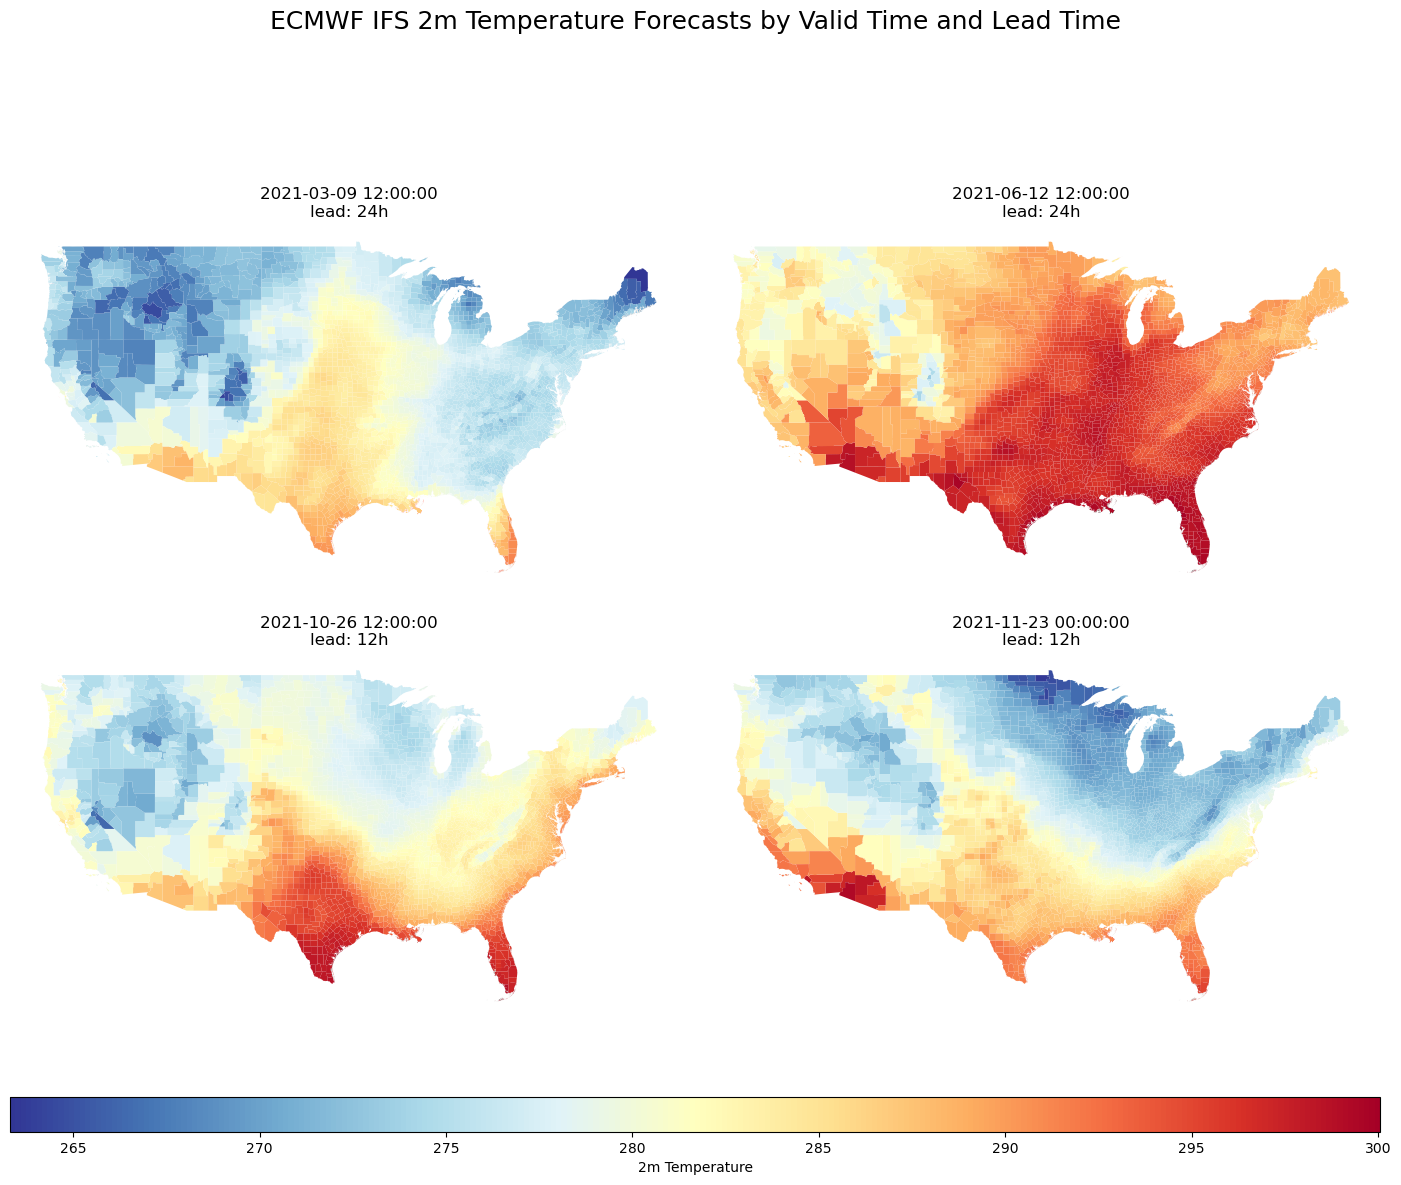

In [14]:
fc_agg.shapefile.rename(columns={'GEOID': 'geo_id'}, inplace=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

vmin, vmax = df_fc['t2m'].min(), df_fc['t2m'].max()
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = 'RdYlBu_r'

for ax, (valid_time, sub) in zip(axes, df_fc.groupby('valid_time')):
    gdf_plot = fc_agg.shapefile.merge(sub[['geo_id', 't2m']], on='geo_id', how='inner')
    gdf_plot.plot(ax=ax, column='t2m', cmap=cmap, norm=norm)
    lead_val = sub['lead_time'].iloc[0]
    ax.set_title(f'{valid_time}\nlead: {lead_val}h')
    ax.set_axis_off()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig.suptitle(
    'ECMWF IFS 2m Temperature Forecasts by Valid Time and Lead Time', 
    fontsize=18, 
    y=0.90  # Move title closer to panels
)
plt.tight_layout(rect=[0, 0.08, 1, 0.94])  # Adjust for space at bottom for colorbar and a bit at top for title

fig.colorbar(
    sm,
    ax=axes.tolist(),
    orientation='horizontal',
    fraction=0.04,
    pad=0.07,
    aspect=40,
    label='2m Temperature'
)
plt.show()